# 1. Library imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import GARCHModel, XGBVolatilityModel, XGBHybridModel
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    dm_matrix,
    mcs,
)

# 2. Configuration

In [ ]:
# ── Input data ───────────────────────────────────────────────────────────────
TICKER          = "BZ=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2026-05-28"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2022-06-30"
TEST_START  = "2022-07-01"
TEST_END    = FULL_DATA_END

# ── Classical econometric model specifications ────────────────────────────────
# Each tuple: (model_type, error_distribution)
# model_type:  'GARCH' | 'GJR-GARCH' | 'EGARCH' | 'APARCH' | 'FIGARCH'
# dist:        'normal' | 't' | 'ged'
GARCH_SPECS = [
    ("GARCH",     "normal"),
    ("GARCH",     "t"),
    ("GARCH",     "ged"),
    ("GJR-GARCH", "normal"),
    ("GJR-GARCH", "t"),
    ("GJR-GARCH", "ged"),
    ("EGARCH",    "normal"),
    ("EGARCH",    "t"),
    ("EGARCH",    "ged"),
    ("APARCH",    "normal"),
    ("APARCH",    "t"),
    ("APARCH",    "ged"),
    ("FIGARCH",   "normal"),
    ("FIGARCH",   "t"),
    ("FIGARCH",   "ged"),
]

# ── Out-of-sample evaluation (shared by all models) ───────────────────────────
N_AHEAD     = 1   # forecast horizon; only 1 is currently supported
REFIT_EVERY = 10  # re-estimate parameters every N test steps

# ── Statistical tests ─────────────────────────────────────────────────────────
TEST_LOSS = "qlike"  # loss for DM test & MCS: 'squared' | 'absolute' | 'qlike'
MCS_ALPHA = 0.05     # MCS significance level
DM_ALPHA  = 0.05     # Diebold-Mariano rejection threshold

# ── Standalone XGBoost ────────────────────────────────────────────────────────
XGB_N_LAGS      = 5      # lagged sq-returns (and raw returns) as features
XGB_USE_RETURNS = True   # include lagged raw returns alongside sq-returns
XGB_USE_OPTUNA  = True  # Optuna hyperparameter search (slower)
XGB_N_TRIALS    = 50     # Optuna trials (ignored when XGB_USE_OPTUNA=False)
XGB_PARAMS      = None   # dict of manual XGBoost params; None → package defaults

# ── Hybrid XGBoost specifications ─────────────────────────────────────────────
# Each tuple: (garch_model_type, garch_dist, mode)
# mode 'features' : XGB predicts variance using GARCH forecast as one feature
# mode 'residual' : final forecast = GARCH_forecast + XGB_residual_correction
HYBRID_SPECS = [
    ("GARCH",     "normal", "features"),
    ("GARCH",     "normal", "residual"),
    ("GJR-GARCH", "t",      "features"),
    ("GJR-GARCH", "t",      "residual"),
    ("EGARCH",    "t",      "features"),
    ("EGARCH",    "t",      "residual"),
]
HYBRID_N_LAGS      = 5
HYBRID_USE_RETURNS = True
HYBRID_USE_OPTUNA  = True 
HYBRID_N_TRIALS    = 50
HYBRID_PARAMS      = None

# 3. Data

In [3]:
data    = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close   = data["Close"].squeeze()
returns = np.log(close / close.shift(1)).dropna()
returns.index = pd.PeriodIndex(returns.index, freq='D')

[*********************100%***********************]  1 of 1 completed


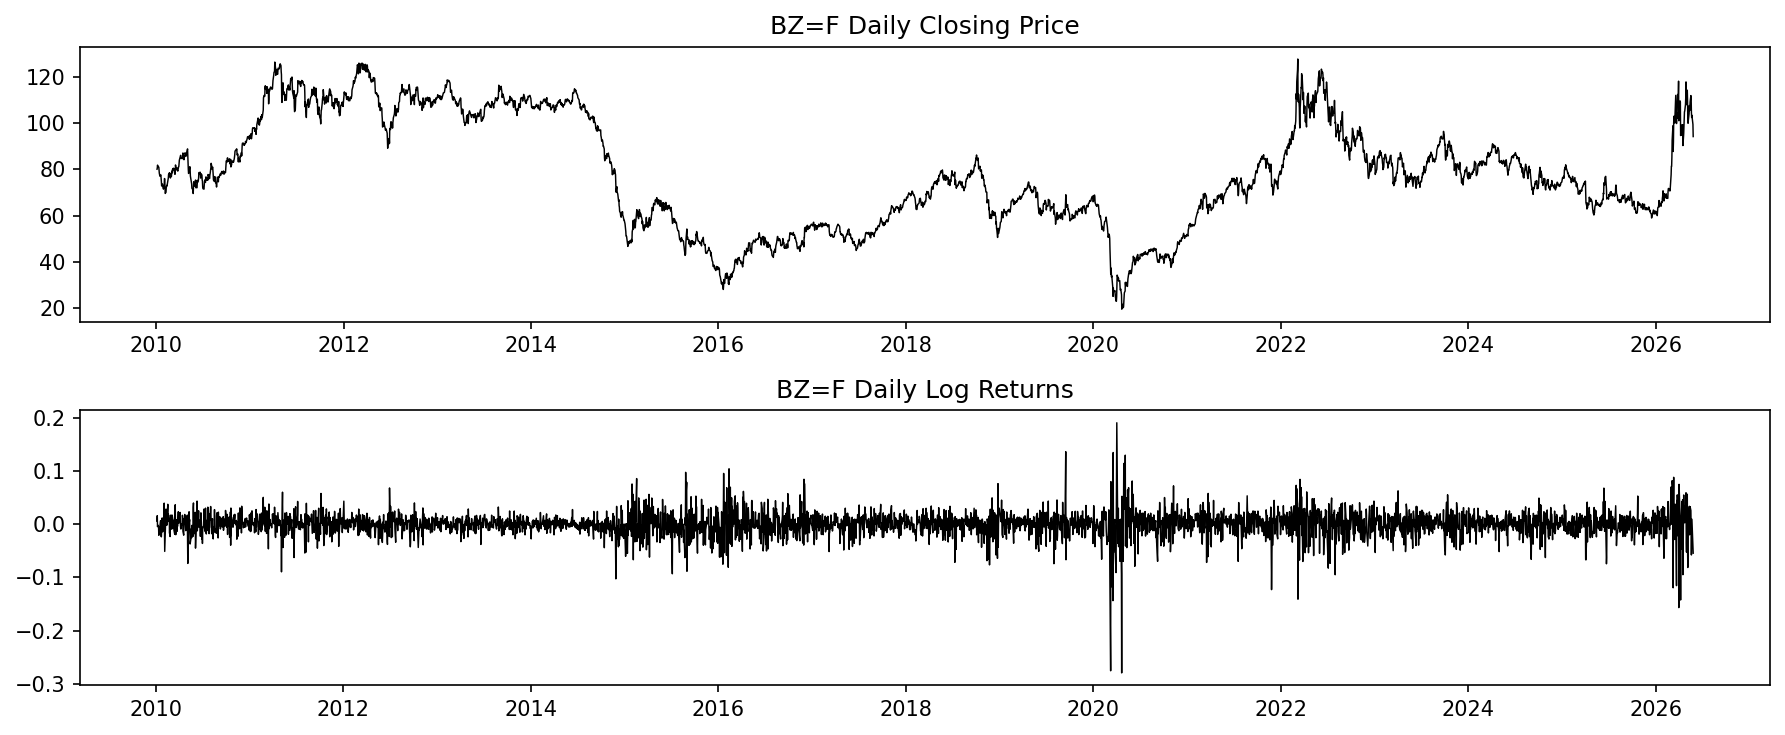

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=150)
axes[0].plot(close, linewidth=0.7, color='black')
axes[0].set_title(f"{TICKER} Daily Closing Price")
axes[1].plot(returns.index.to_timestamp(), returns.values, linewidth=0.7, color='black')
axes[1].set_title(f"{TICKER} Daily Log Returns")
plt.tight_layout()
plt.show()

In [5]:
def get_stats_and_ks(series, name):
    stats = series.describe()
    ks_stat, ks_pval = kstest(series, 'norm', args=(series.mean(), series.std()))
    return {
        'count': stats['count'], 'mean': stats['mean'], 'std': stats['std'],
        'min': stats['min'], 'max': stats['max'],
        'range': stats['max'] - stats['min'],
        'skewness': skew(series), 'kurtosis': kurtosis(series),
        'KS_stat': ks_stat, 'KS_pval': ks_pval, 'Name': name,
    }

stats_df = pd.DataFrame([get_stats_and_ks(returns, "Full Returns")]).set_index('Name')
stats_df

,count,mean,std,min,max,range,skewness,kurtosis,KS_stat,KS_pval
Name,,,,,,,,,,
Full Returns,4092.0,0.00004,0.023238,-0.279761,0.190774,0.470536,-0.998553,15.338745,0.086848,2.653574e-27


In [6]:
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[returns.index >= TEST_START]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")

Train: 2010-01-05  →  2022-06-30  (3110 obs)
Test:  2022-07-01  →  2026-05-27  (982 obs)


# 4. Classical Econometric Models (GARCH Family)

Five volatility specifications × three error distributions = 15 models.

| Spec | Description |
|------|-------------|
| GARCH | Standard symmetric GARCH(1,1) — Bollerslev (1986) |
| GJR-GARCH | Asymmetric leverage effect via indicator term — Glosten et al. (1993) |
| EGARCH | Log-variance equation, asymmetric — Nelson (1991) |
| APARCH | Asymmetric power ARCH — Ding et al. (1993) |
| FIGARCH | Fractionally integrated long-memory variance — Baillie et al. (1996) |

## 4.1 In-sample fit

In [7]:
insample_models: dict[str, GARCHModel] = {}
ic_rows = []

for model_type, dist in GARCH_SPECS:
    name  = f"{model_type}-{dist.upper()}"
    model = GARCHModel(model_type, dist)
    try:
        model.fit(train_returns)
        insample_models[name] = model
        row = model.info_criteria()
        row["Model"] = name
        ic_rows.append(row)
    except Exception as exc:
        print(f"  [WARNING] {name} failed: {exc}")

ic_df = (
    pd.DataFrame(ic_rows)
    .set_index("Model")
    .sort_values("BIC")
    [["LogL", "AIC", "BIC"]]
)
print(f"Fitted {len(insample_models)} / {len(GARCH_SPECS)} models")
ic_df

Fitted 15 / 15 models


,LogL,AIC,BIC
Model,,,
GJR-GARCH-T,-6264.173946,12540.347891,12576.602159
EGARCH-T,-6269.597063,12549.194126,12579.406016
GARCH-T,-6269.988512,12549.977024,12580.188914
APARCH-T,-6268.701121,12549.402242,12585.656510
FIGARCH-T,-6269.000674,12550.001349,12586.255617
GJR-GARCH-GED,-6276.601527,12565.203054,12601.457322
EGARCH-GED,-6282.924362,12575.848724,12606.060615
GARCH-GED,-6283.617069,12577.234138,12607.446028
APARCH-GED,-6282.159283,12576.318566,12612.572834


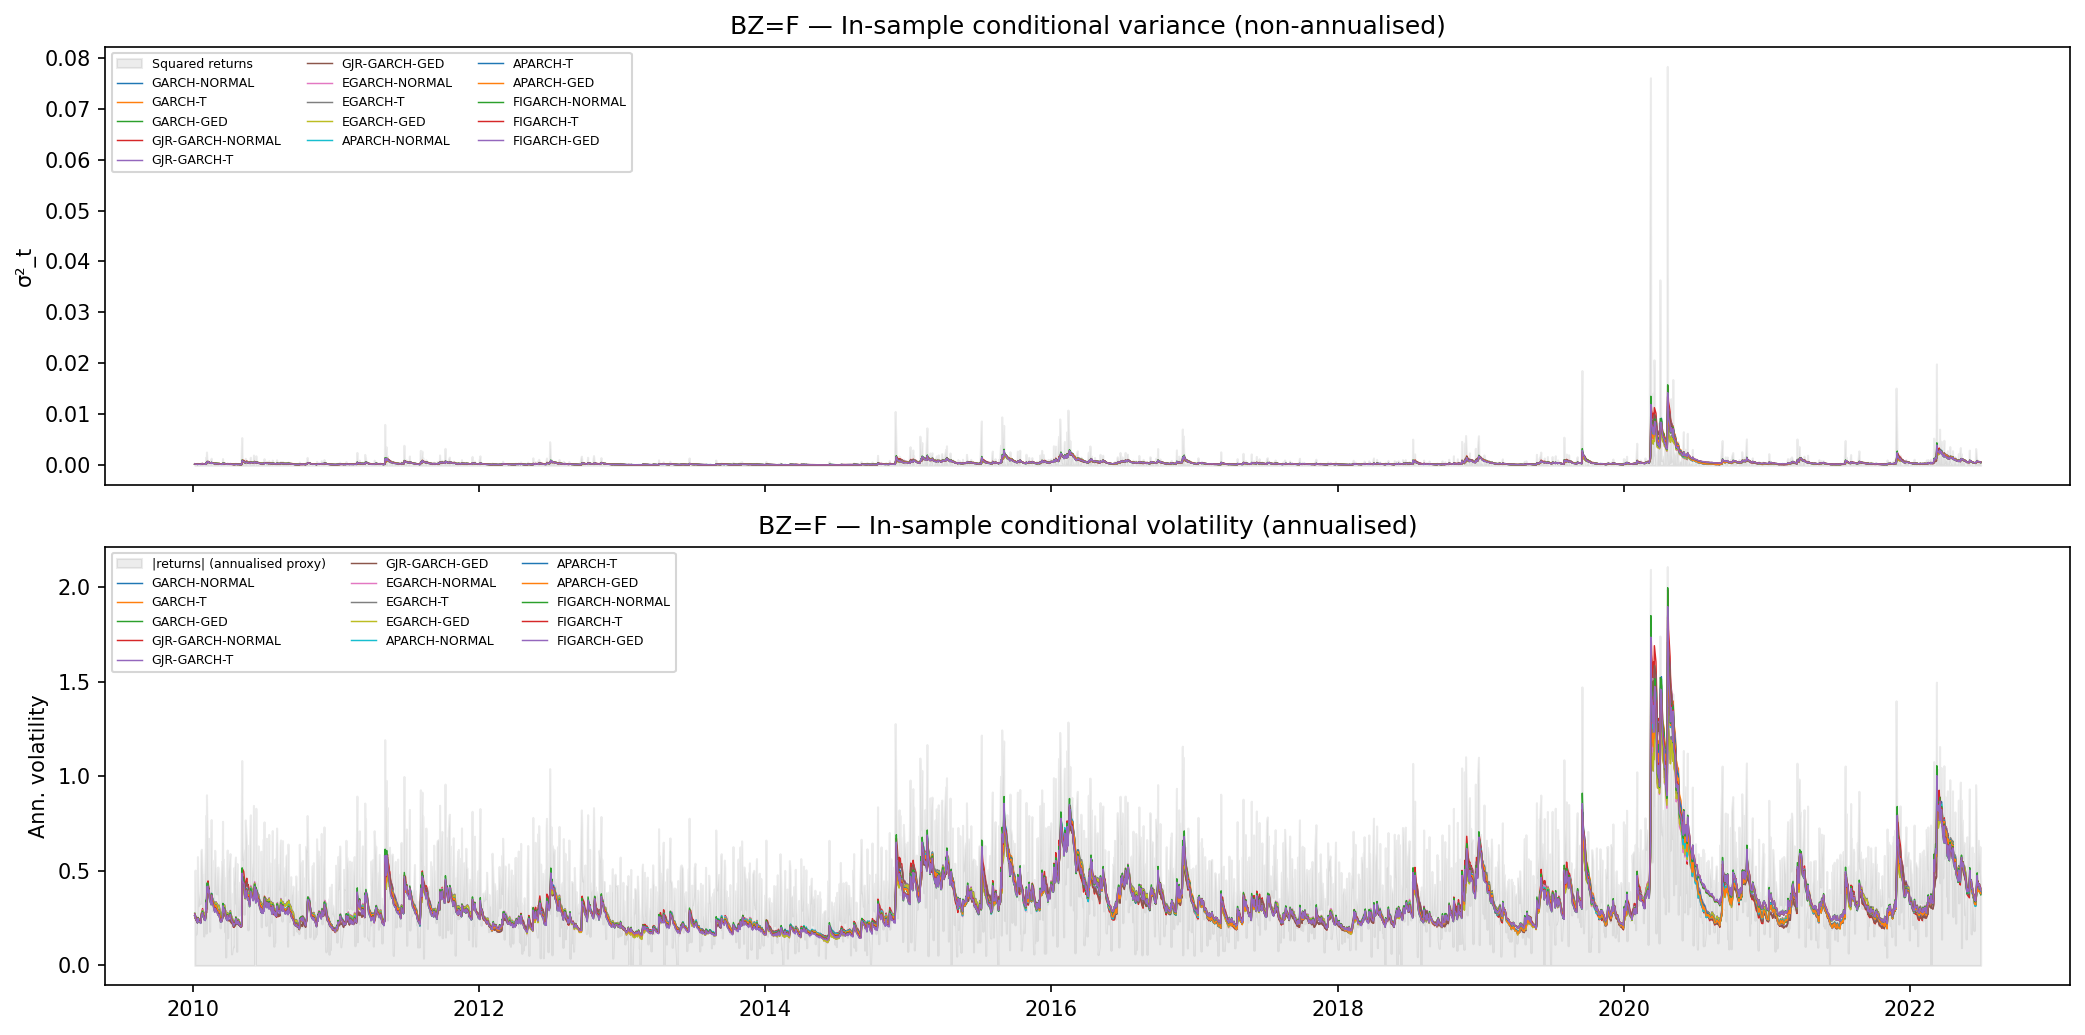

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), dpi=150, sharex=True)

# Raw variance
axes[0].fill_between(
    train_returns.index.to_timestamp(),
    train_returns.values ** 2,
    alpha=0.15, color="gray", label="Squared returns",
)
for name, model in insample_models.items():
    cv = model.insample_variance()
    axes[0].plot(cv.index.to_timestamp(), cv.values, linewidth=0.7, label=name)
axes[0].set_title(f"{TICKER} — In-sample conditional variance (non-annualised)")
axes[0].set_ylabel("σ²_t")
axes[0].legend(fontsize=6, ncol=3)

# Annualised volatility
axes[1].fill_between(
    train_returns.index.to_timestamp(),
    np.sqrt(np.abs(train_returns.values) * np.sqrt(252)),
    alpha=0.15, color="gray", label="|returns| (annualised proxy)",
)
for name, model in insample_models.items():
    cv = model.insample_variance()
    axes[1].plot(cv.index.to_timestamp(), np.sqrt(cv.values * 252), linewidth=0.7, label=name)
axes[1].set_title(f"{TICKER} — In-sample conditional volatility (annualised)")
axes[1].set_ylabel("Ann. volatility")
axes[1].legend(fontsize=6, ncol=3)

plt.tight_layout()
plt.show()

## 4.2 Out-of-sample evaluation

Recursive expanding-window, 1-step-ahead.  
Parameters re-estimated every `REFIT_EVERY` steps.  
Realized variance proxy: squared log-return.

In [9]:
evaluator = RollingEvaluator(n_ahead=N_AHEAD, refit_every=REFIT_EVERY)

garch_eval_specs = [
    (lambda t=t, d=d: GARCHModel(t, d), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs, train_returns, test_returns, verbose=True
)
print(f"\nCompleted {len(garch_results)} GARCH models.")

Evaluating GARCH-NORMAL...
  [GARCH-NORMAL] re-fitted at step 0/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 10/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 20/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 30/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 40/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 50/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 60/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 70/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 80/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 90/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 100/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 110/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 120/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 130/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 140/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 150/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 160/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 170/982 (expan

In [10]:
garch_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
garch_metrics_df

,RMSE,MAE,MSE,QLIKE
EGARCH-T,0.001424,0.000592,0.000002,-6.573449
EGARCH-GED,0.001424,0.000587,0.000002,-6.565022
EGARCH-NORMAL,0.001426,0.000594,0.000002,-6.553742
APARCH-GED,0.001431,0.000591,0.000002,-6.566444
APARCH-T,0.001432,0.000592,0.000002,-6.575043
APARCH-NORMAL,0.001435,0.000600,0.000002,-6.558086
GARCH-GED,0.001437,0.000595,0.000002,-6.566567
GARCH-T,0.001439,0.000600,0.000002,-6.575264
FIGARCH-GED,0.001440,0.000595,0.000002,-6.550407
GARCH-NORMAL,0.001441,0.000603,0.000002,-6.560343


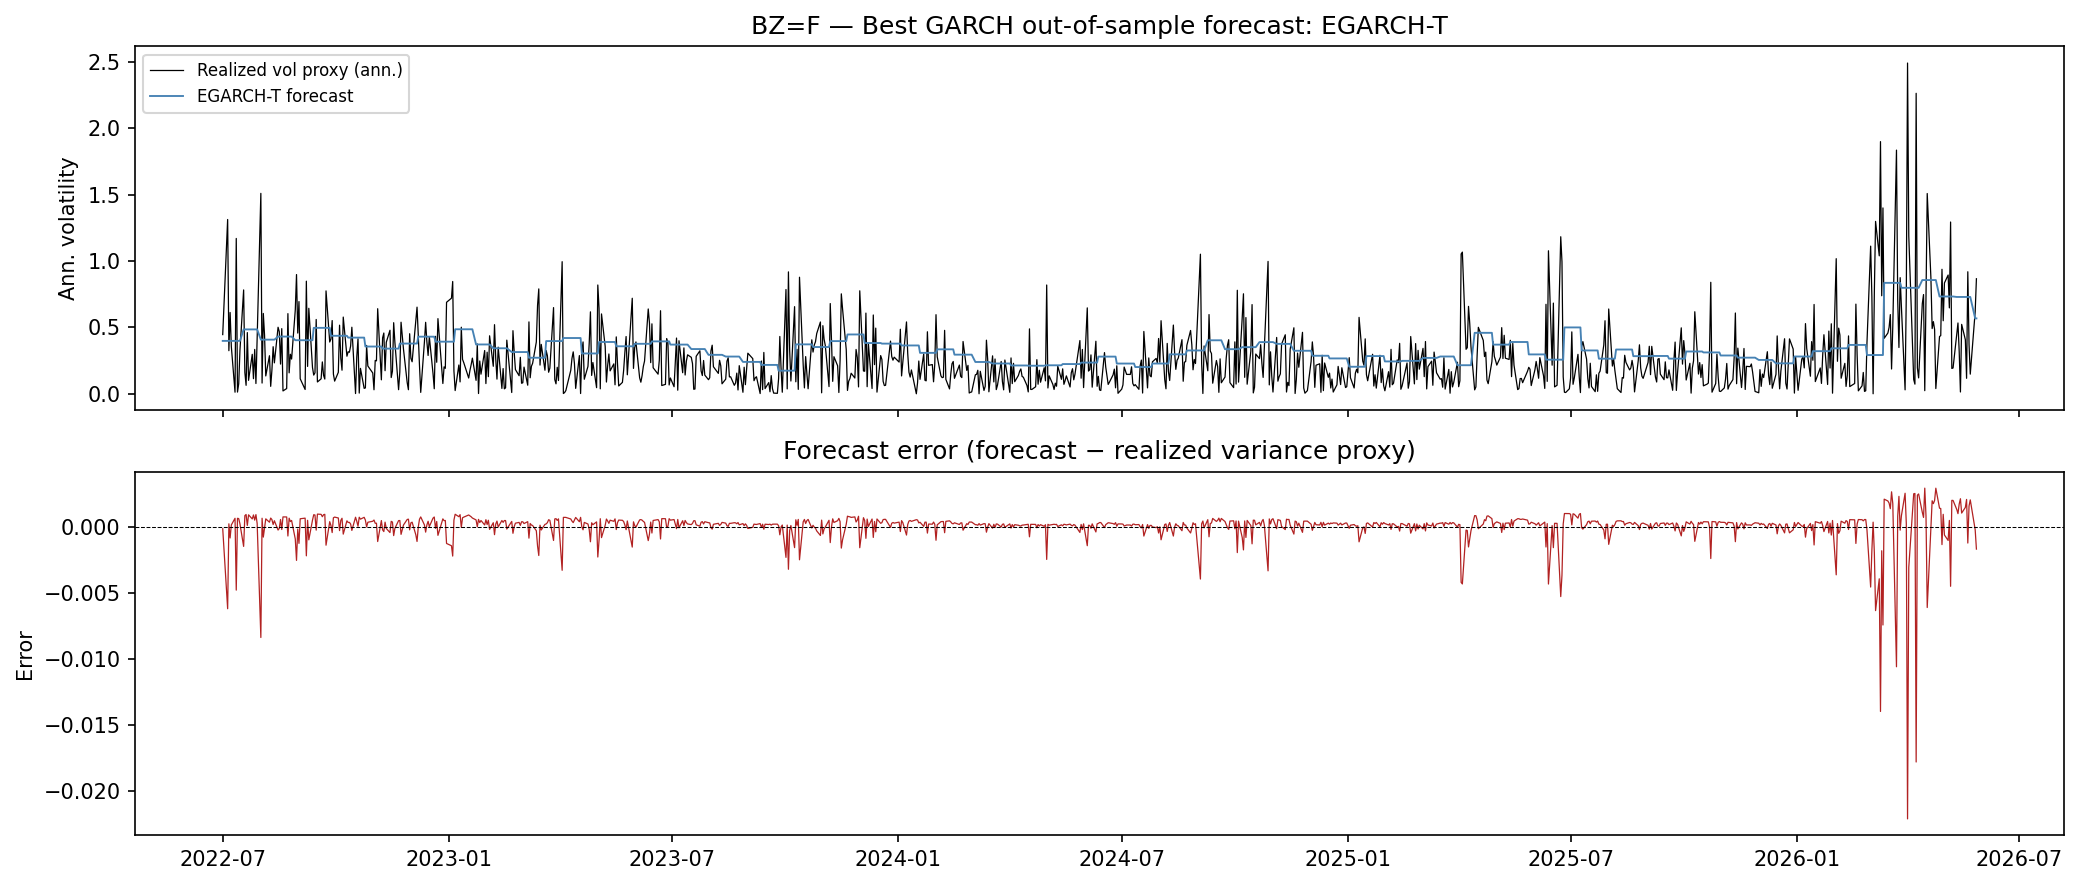

In [11]:
best_garch_name = garch_metrics_df.index[0]
r = garch_results[best_garch_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r.actuals.index.to_timestamp(), np.sqrt(r.actuals.values * 252),
             color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r.forecasts.index.to_timestamp(), np.sqrt(r.forecasts.values * 252),
             color='steelblue', linewidth=0.9, label=f'{best_garch_name} forecast')
axes[0].set_title(f"{TICKER} — Best GARCH out-of-sample forecast: {best_garch_name}")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r.errors.index.to_timestamp(), r.errors.values, color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()

# 5. Standalone XGBoost

XGBoost regressor trained directly on lagged squared returns (realized variance proxies) and, optionally, lagged raw returns.  
No distributional assumptions — the model learns the mapping from lagged features to next-step variance.  
Hyperparameters can be tuned via Optuna (set `XGB_USE_OPTUNA = True` in config).

## 5.1 Out-of-sample evaluation

In [12]:
xgb_eval_specs = [
    (
        lambda: XGBVolatilityModel(
            n_lags=XGB_N_LAGS,
            use_returns=XGB_USE_RETURNS,
            use_optuna=XGB_USE_OPTUNA,
            n_trials=XGB_N_TRIALS,
            xgb_params=XGB_PARAMS,
        ),
        "XGB-Standalone",
    )
]

xgb_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    xgb_eval_specs, train_returns, test_returns, verbose=True
)
print(f"\nCompleted {len(xgb_results)} standalone XGB model(s).")

Evaluating XGB-Standalone...


/opt/anaconda3/envs/volatility-pipeline-new/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [XGB-Standalone] re-fitted at step 0/982 (expanding)
  [XGB-Standalone] re-fitted at step 10/982 (expanding)
  [XGB-Standalone] re-fitted at step 20/982 (expanding)
  [XGB-Standalone] re-fitted at step 30/982 (expanding)
  [XGB-Standalone] re-fitted at step 40/982 (expanding)
  [XGB-Standalone] re-fitted at step 50/982 (expanding)
  [XGB-Standalone] re-fitted at step 60/982 (expanding)
  [XGB-Standalone] re-fitted at step 70/982 (expanding)
  [XGB-Standalone] re-fitted at step 80/982 (expanding)
  [XGB-Standalone] re-fitted at step 90/982 (expanding)
  [XGB-Standalone] re-fitted at step 100/982 (expanding)
  [XGB-Standalone] re-fitted at step 110/982 (expanding)
  [XGB-Standalone] re-fitted at step 120/982 (expanding)
  [XGB-Standalone] re-fitted at step 130/982 (expanding)
  [XGB-Standalone] re-fitted at step 140/982 (expanding)
  [XGB-Standalone] re-fitted at step 150/982 (expanding)
  [XGB-Standalone] re-fitted at step 160/982 (expanding)
  [XGB-Standalone] re-fitted at step 170/9

In [13]:
xgb_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in xgb_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
xgb_metrics_df

,RMSE,MAE,MSE,QLIKE
XGB-Standalone,0.001599,0.000663,0.000003,-6.517823


## 5.2 Feature importance

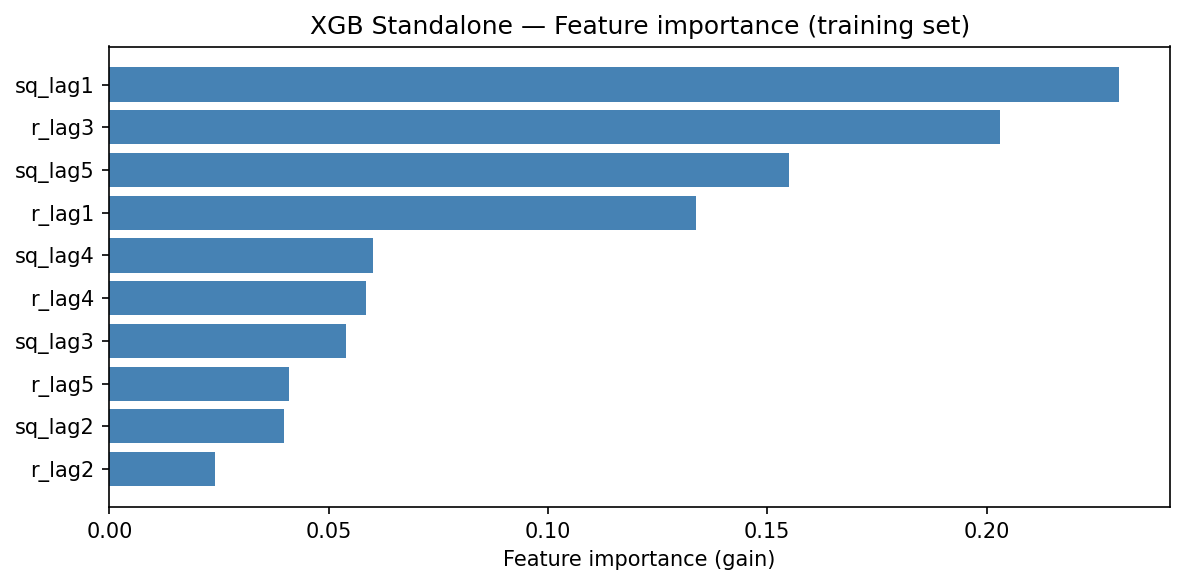

In [14]:
# Fit once on training data for inspection (separate from the rolling evaluation)
xgb_viz = XGBVolatilityModel(
    n_lags=XGB_N_LAGS, use_returns=XGB_USE_RETURNS,
    use_optuna=False, xgb_params=XGB_PARAMS,
)
xgb_viz.fit(train_returns)

feat_names   = xgb_viz.feature_names()
importances  = xgb_viz._model.feature_importances_
order        = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, max(3, len(feat_names) * 0.4)), dpi=150)
ax.barh([feat_names[i] for i in order], importances[order], color='steelblue')
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGB Standalone — Feature importance (training set)")
plt.tight_layout()
plt.show()

## 5.3 Forecast vs realized

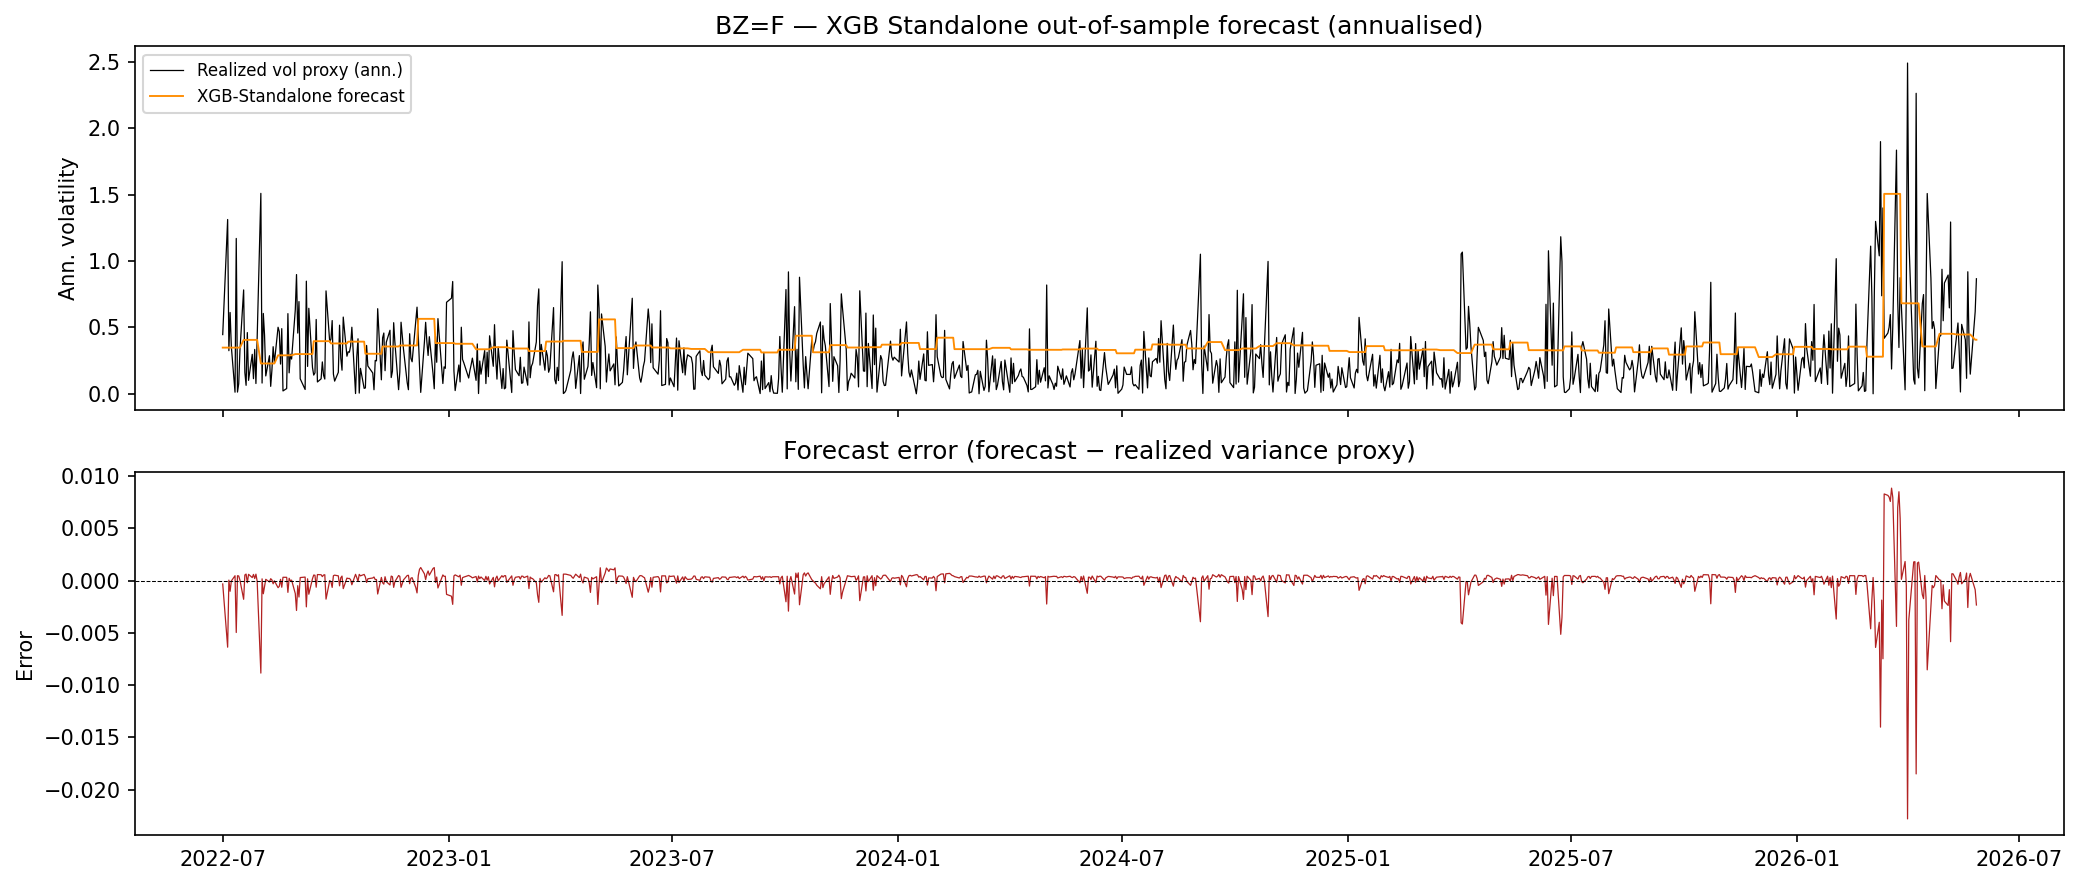

In [15]:
r_xgb = xgb_results["XGB-Standalone"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r_xgb.actuals.index.to_timestamp(), np.sqrt(r_xgb.actuals.values * 252),
             color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r_xgb.forecasts.index.to_timestamp(), np.sqrt(r_xgb.forecasts.values * 252),
             color='darkorange', linewidth=0.9, label='XGB-Standalone forecast')
axes[0].set_title(f"{TICKER} — XGB Standalone out-of-sample forecast (annualised)")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r_xgb.errors.index.to_timestamp(), r_xgb.errors.values,
             color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()

# 6. Hybrid XGBoost

Two hybrid architectures evaluated for each GARCH base model specified in `HYBRID_SPECS`:

| Mode | Description |
|------|-------------|
| `features` | XGB predicts variance directly; GARCH one-step forecast h_{t+1\|t} is included as an additional feature alongside lagged returns. |
| `residual` | **Residual correction**: final forecast = GARCH_forecast + XGB_residual, where XGB is trained to predict the in-sample GARCH residual (r²_t − h_{t\|t-1}). |

## 6.1 Out-of-sample evaluation

In [16]:
_mode_short = {"features": "feat", "residual": "resid"}

hybrid_eval_specs = [
    (
        lambda gt=gt, gd=gd, m=m: XGBHybridModel(
            garch_model_type=gt,
            garch_dist=gd,
            mode=m,
            n_lags=HYBRID_N_LAGS,
            use_returns=HYBRID_USE_RETURNS,
            use_optuna=HYBRID_USE_OPTUNA,
            n_trials=HYBRID_N_TRIALS,
            xgb_params=HYBRID_PARAMS,
        ),
        f"XGB-{gt}-{gd.upper()}-{_mode_short[m]}",
    )
    for gt, gd, m in HYBRID_SPECS
]

hybrid_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    hybrid_eval_specs, train_returns, test_returns, verbose=True
)
print(f"\nCompleted {len(hybrid_results)} hybrid model(s).")

Evaluating XGB-GARCH-NORMAL-feat...
  [XGB-GARCH-NORMAL-feat] re-fitted at step 0/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 10/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 20/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 30/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 40/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 50/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 60/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 70/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 80/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 90/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 100/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 110/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 120/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 130/982 (expanding)
  [XGB-GARCH-NORMAL-feat] re-fitted at step 140/982 (expanding)
  [XGB-GARCH-NO

[W 2026-05-30 15:47:46,358] Trial 1 failed with parameters: {'n_estimators': 321, 'max_depth': 6, 'learning_rate': 0.010725209743171997, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 5, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 0.0008260808399079611} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/envs/volatility-pipeline-new/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/Users/szymonstolarski/Library/CloudStorage/OneDrive-UniwersytetEkonomicznywKatowicach/Doktorat/pipeline may 2026/volatility-pipeline/volatility_pipeline/models/xgb_models.py", line 47, in objective
    m.fit(X_tr, y_tr)
    ~~~~~^^^^^^^^^^^^
  File "/opt/anaconda3/envs/volatility-pipeline-new/lib/python3.14/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/envs/volatility-pip

KeyboardInterrupt: 

In [ ]:
hybrid_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in hybrid_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
hybrid_metrics_df

,RMSE,MAE,MSE,QLIKE
XGB-GARCH-NORMAL-feat,0.001478,0.000611,0.000002,-6.633206
XGB-EGARCH-T-feat,0.001490,0.000609,0.000002,-6.610935
XGB-GJR-GARCH-T-feat,0.001504,0.000619,0.000002,-6.627278
XGB-EGARCH-T-resid,0.001514,0.000624,0.000002,-6.583788
XGB-GJR-GARCH-T-resid,0.001542,0.000631,0.000002,-6.521325
XGB-GARCH-NORMAL-resid,0.001544,0.000633,0.000002,-6.539787


## 6.2 Feature importance (hybrid models)

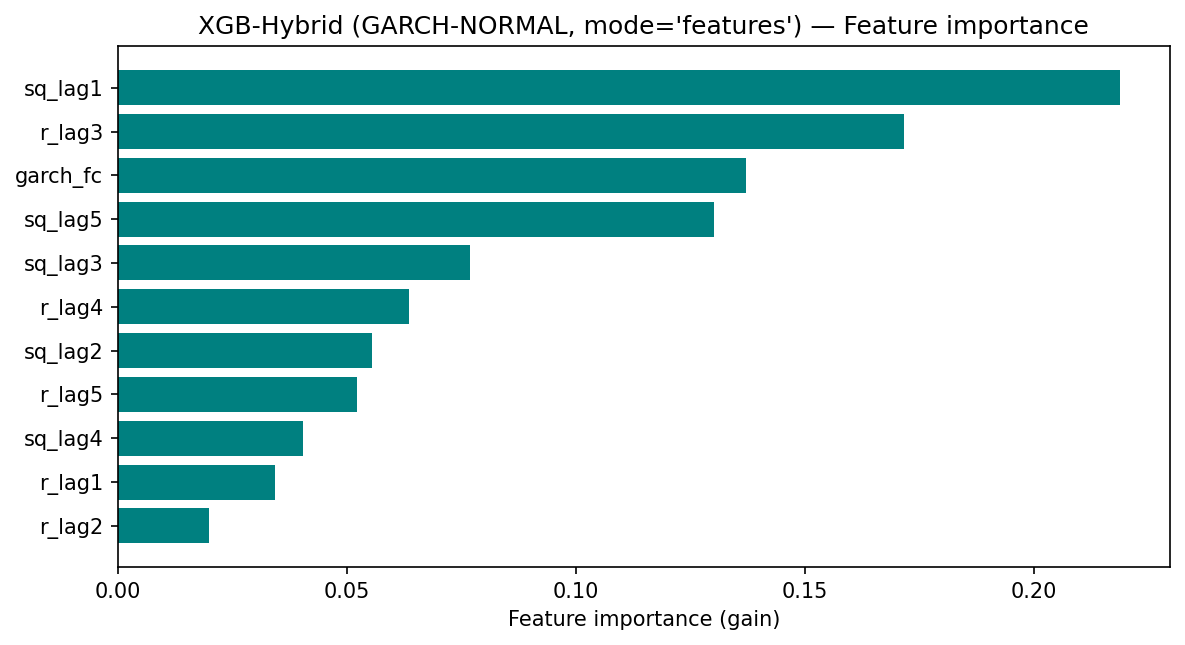

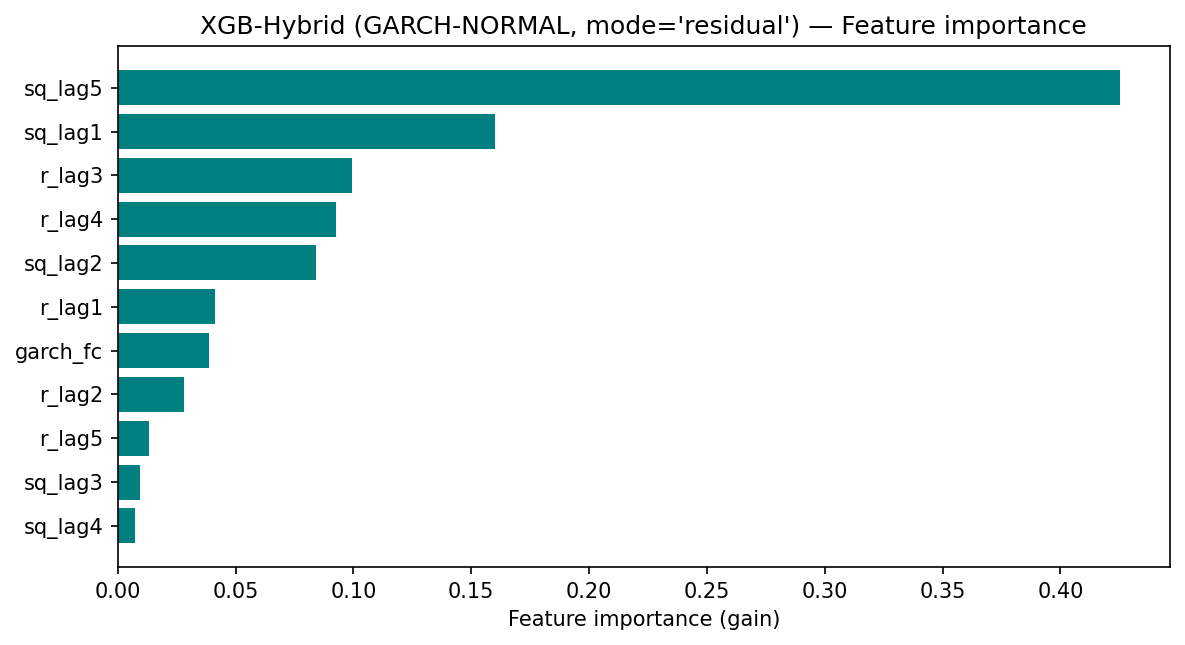

In [ ]:
# Fit one representative hybrid model per mode for inspection
# Uses the first spec for each mode found in HYBRID_SPECS
from collections import OrderedDict

viz_specs = OrderedDict()
for gt, gd, m in HYBRID_SPECS:
    if m not in viz_specs:
        viz_specs[m] = (gt, gd)

for mode, (gt, gd) in viz_specs.items():
    h_viz = XGBHybridModel(
        garch_model_type=gt, garch_dist=gd, mode=mode,
        n_lags=HYBRID_N_LAGS, use_returns=HYBRID_USE_RETURNS,
        use_optuna=False, xgb_params=HYBRID_PARAMS,
    )
    h_viz.fit(train_returns)

    feat_names  = h_viz.feature_names()
    importances = h_viz._xgb.feature_importances_
    order       = np.argsort(importances)

    fig, ax = plt.subplots(figsize=(8, max(3, len(feat_names) * 0.4)), dpi=150)
    ax.barh([feat_names[i] for i in order], importances[order], color='teal')
    ax.set_xlabel("Feature importance (gain)")
    ax.set_title(f"XGB-Hybrid ({gt}-{gd.upper()}, mode='{mode}') — Feature importance")
    plt.tight_layout()
    plt.show()

## 6.3 Residual decomposition (residual-correction models)

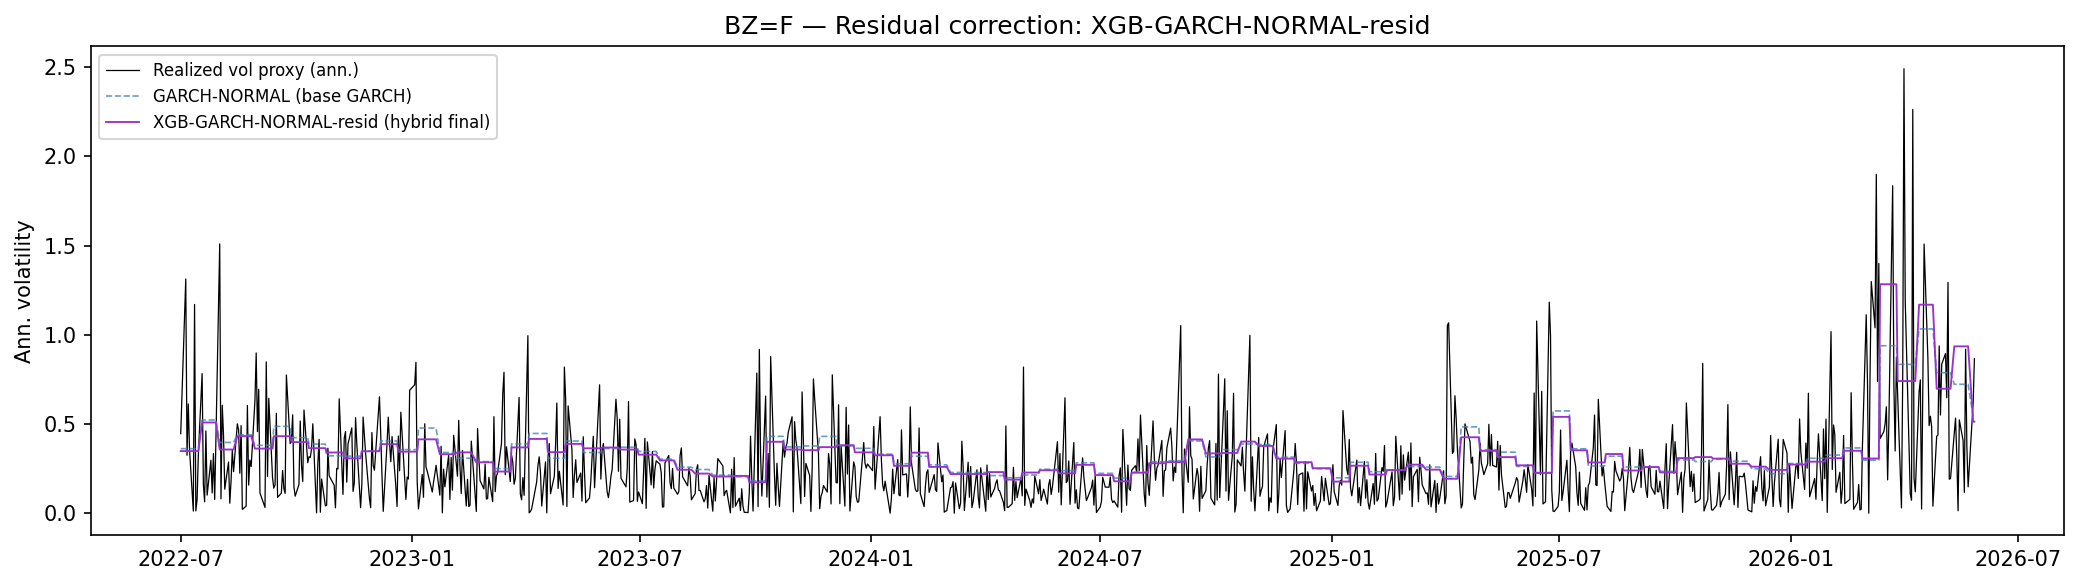

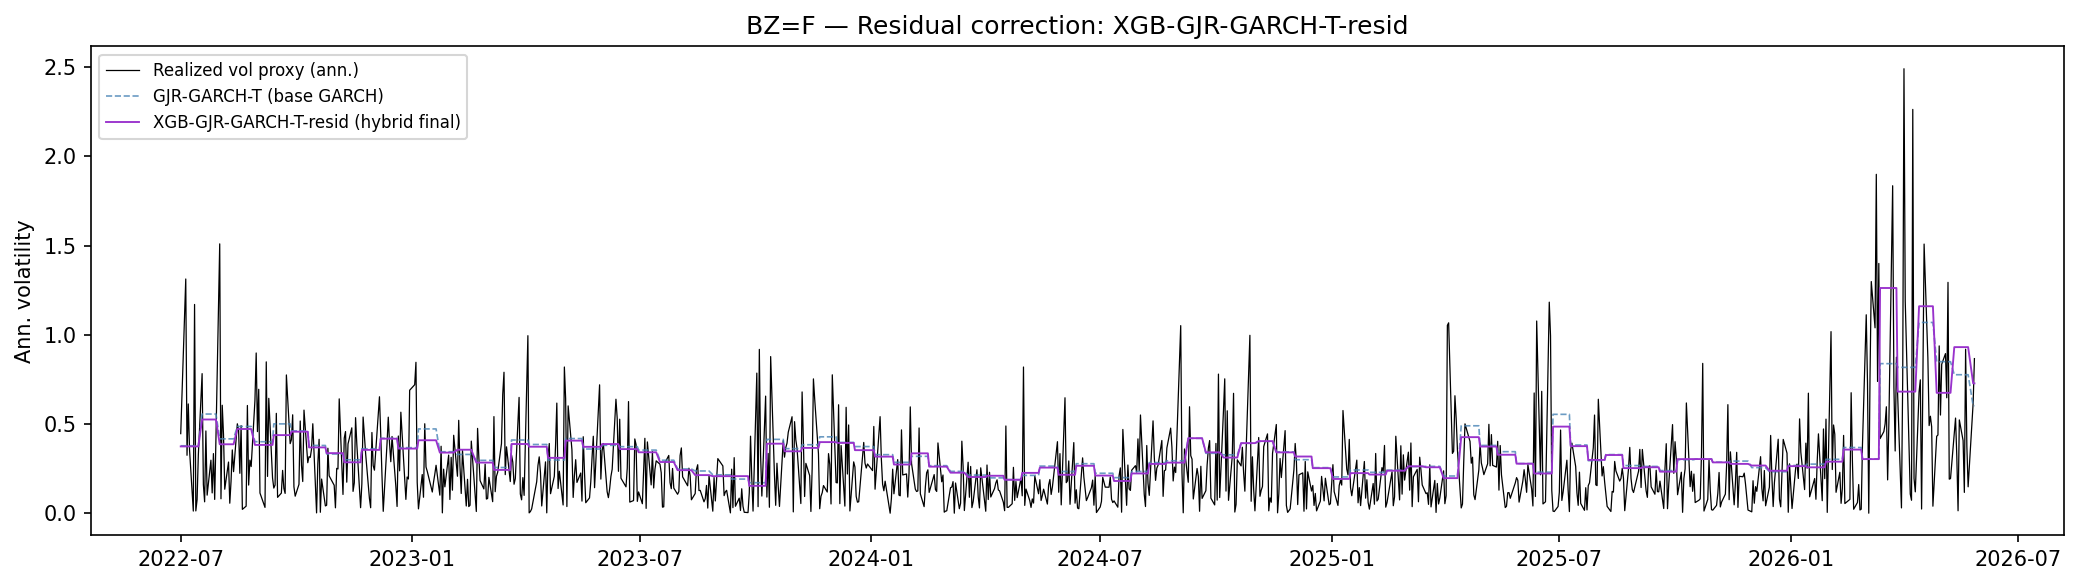

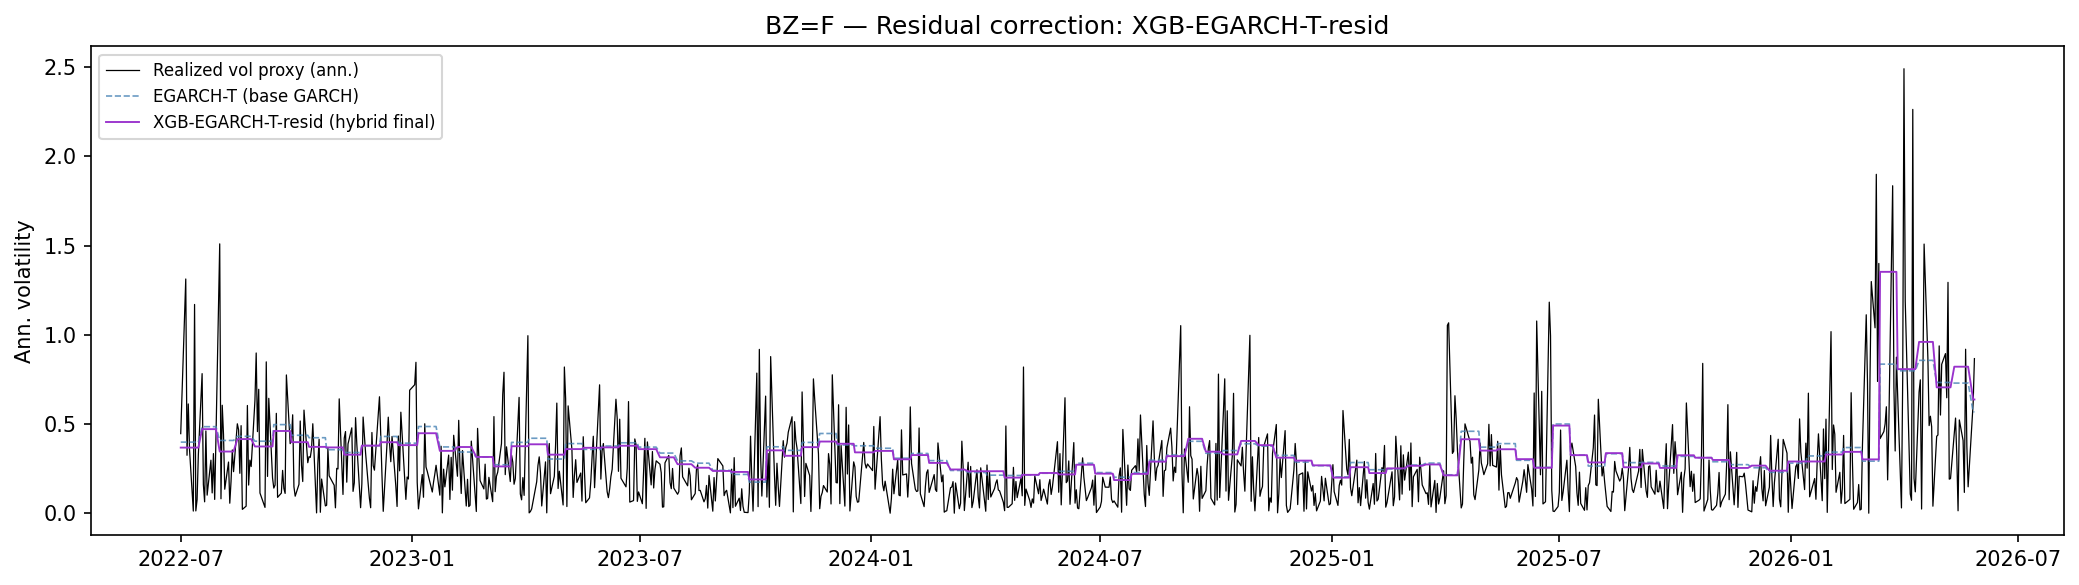

In [ ]:
# For each residual-mode hybrid in the results, plot the decomposition:
#   realized variance, GARCH standalone forecast, and final hybrid forecast

resid_names = [name for name in hybrid_results if name.endswith("-resid")]

# Identify corresponding GARCH standalone result for each residual hybrid
for h_name in resid_names:
    # derive base GARCH name from hybrid name, e.g. XGB-GARCH-NORMAL-resid → GARCH-NORMAL
    parts      = h_name.split("-")  # ['XGB', 'GARCH', 'NORMAL', 'resid']
    garch_name = "-".join(parts[1:-1])  # 'GARCH-NORMAL'

    r_h  = hybrid_results[h_name]
    r_g  = garch_results.get(garch_name)

    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    ax.plot(r_h.actuals.index.to_timestamp(), np.sqrt(r_h.actuals.values * 252),
            color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
    if r_g is not None:
        ax.plot(r_g.forecasts.index.to_timestamp(), np.sqrt(r_g.forecasts.values * 252),
                color='steelblue', linewidth=0.8, linestyle='--', label=f'{garch_name} (base GARCH)', alpha=0.8)
    ax.plot(r_h.forecasts.index.to_timestamp(), np.sqrt(r_h.forecasts.values * 252),
            color='darkorchid', linewidth=0.9, label=f'{h_name} (hybrid final)')
    ax.set_title(f"{TICKER} — Residual correction: {h_name}")
    ax.set_ylabel("Ann. volatility")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# 7. Joint Evaluation — All Models

Combined metrics table and forecast overlay across all three model groups.

In [ ]:
all_results: dict[str, ForecastResult] = {
    **garch_results,
    **xgb_results,
    **hybrid_results,
}

def _group(name: str) -> str:
    if name.startswith("XGB-") and "-feat" in name:
        return "Hybrid (features)"
    if name.startswith("XGB-") and "-resid" in name:
        return "Hybrid (residual)"
    if name.startswith("XGB-"):
        return "Standalone XGB"
    return "GARCH"

all_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in all_results.items()})
    .T
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
all_metrics_df.insert(0, "Group", all_metrics_df.index.map(_group))
all_metrics_df = all_metrics_df.sort_values(["Group", "RMSE"])
all_metrics_df

,Group,RMSE,MAE,MSE,QLIKE
EGARCH-T,GARCH,0.001424,0.000592,0.000002,-6.573449
EGARCH-GED,GARCH,0.001424,0.000587,0.000002,-6.565022
EGARCH-NORMAL,GARCH,0.001426,0.000594,0.000002,-6.553742
APARCH-GED,GARCH,0.001431,0.000591,0.000002,-6.566444
APARCH-T,GARCH,0.001432,0.000592,0.000002,-6.575043
APARCH-NORMAL,GARCH,0.001435,0.000600,0.000002,-6.558086
GARCH-GED,GARCH,0.001437,0.000595,0.000002,-6.566567
GARCH-T,GARCH,0.001439,0.000600,0.000002,-6.575264
FIGARCH-GED,GARCH,0.001440,0.000595,0.000002,-6.550407
GARCH-NORMAL,GARCH,0.001441,0.000603,0.000002,-6.560343


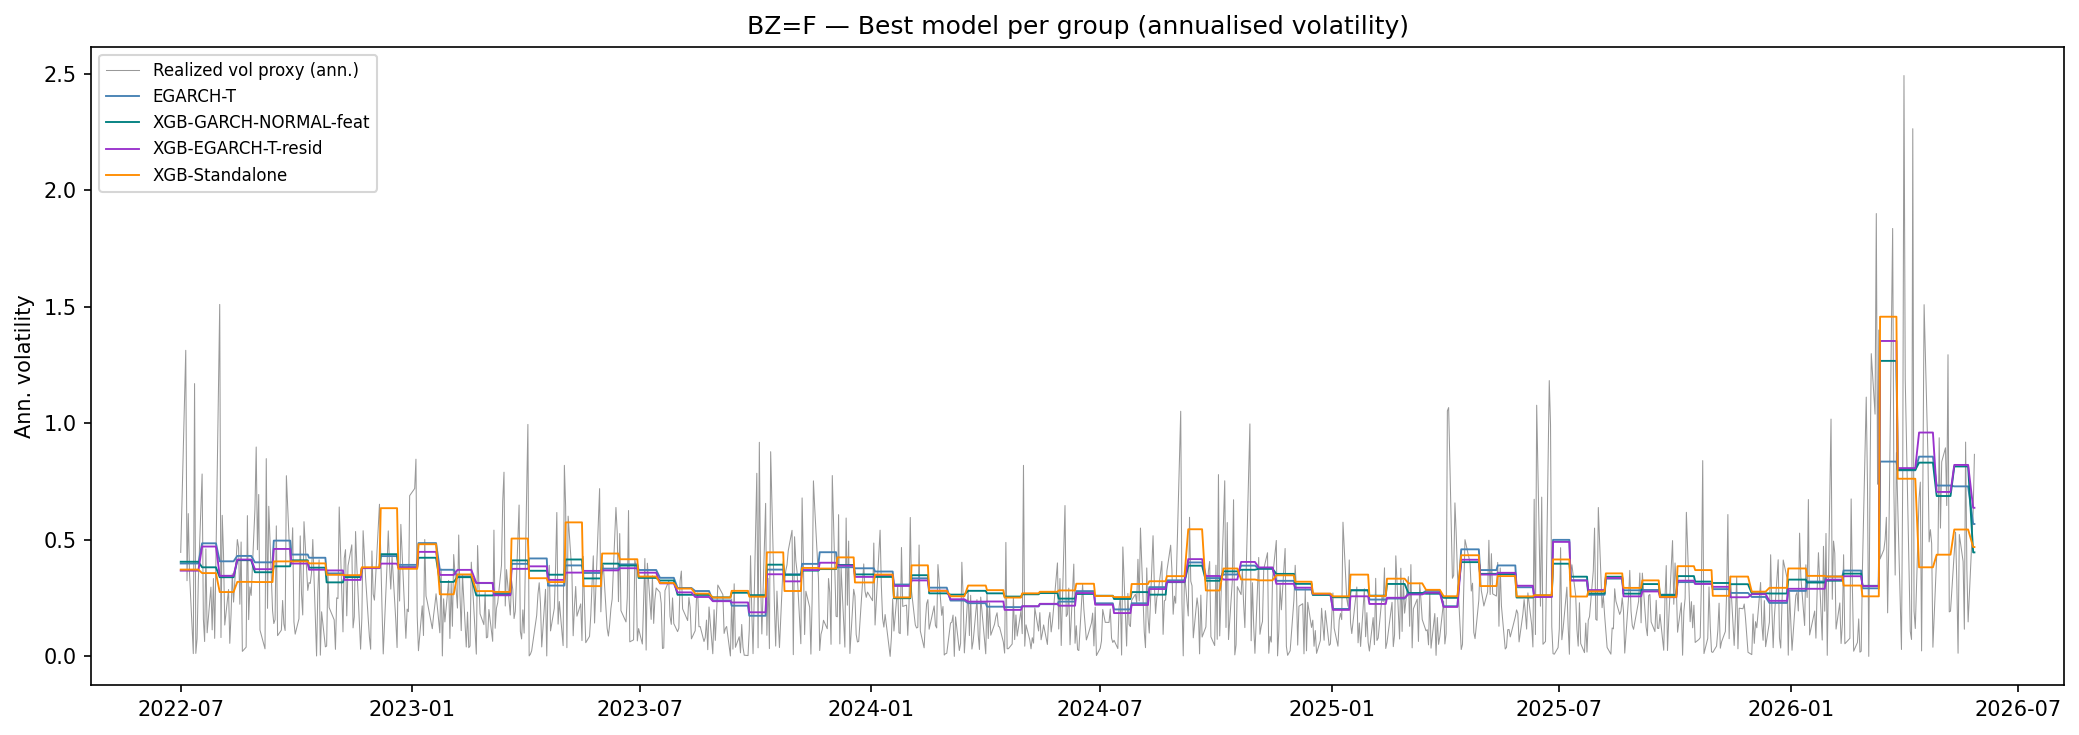

In [ ]:
# Best model per group + realized variance overlay
groups = all_metrics_df["Group"].unique()
palette = {"GARCH": "steelblue", "Standalone XGB": "darkorange",
           "Hybrid (features)": "teal", "Hybrid (residual)": "darkorchid"}

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)
# realized vol proxy (use any result's actuals — they are identical)
ref = next(iter(all_results.values()))
ax.plot(ref.actuals.index.to_timestamp(), np.sqrt(ref.actuals.values * 252),
        color='black', linewidth=0.5, alpha=0.4, label='Realized vol proxy (ann.)')

for grp in groups:
    best_name = all_metrics_df[all_metrics_df["Group"] == grp].sort_values("RMSE").index[0]
    r = all_results[best_name]
    ax.plot(r.forecasts.index.to_timestamp(), np.sqrt(r.forecasts.values * 252),
            linewidth=0.9, label=f"{best_name}", color=palette.get(grp, 'gray'))

ax.set_title(f"{TICKER} — Best model per group (annualised volatility)")
ax.set_ylabel("Ann. volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 8. Statistical Tests

All model groups evaluated jointly.

## 8.1 Diebold-Mariano Test (HLN correction)

Pairwise test of equal predictive accuracy (Harvey, Leybourne & Newbold 1997).  
H₀: models *i* and *j* have equal expected loss.  
Negative MDM statistic → row model has lower loss than column model.  
p-values two-sided from *t*(T−1).

In [ ]:
dm_stat_df, dm_pval_df = dm_matrix(all_results, h=N_AHEAD, loss=TEST_LOSS)

print("MDM statistics (upper triangle):")
dm_stat_df.round(3)

MDM statistics (upper triangle):


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,...,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED,XGB-Standalone,XGB-GARCH-NORMAL-feat,XGB-GARCH-NORMAL-resid,XGB-GJR-GARCH-T-feat,XGB-GJR-GARCH-T-resid,XGB-EGARCH-T-feat,XGB-EGARCH-T-resid
GARCH-NORMAL,NaN,3.06,2.241,-3.479,0.145,-1.523,-0.535,1.144,0.417,-0.561,...,-1.190,-0.227,-0.756,-0.985,2.775,-1.997,2.638,-2.360,1.791,2.018
GARCH-T,NaN,NaN,-2.952,-4.180,-2.731,-3.494,-1.547,-0.159,-0.841,-2.275,...,-1.766,-1.180,-1.495,-1.289,2.200,-3.297,2.031,-3.307,1.204,0.761
GARCH-GED,NaN,NaN,NaN,-4.183,-1.051,-2.906,-0.967,0.581,-0.130,-1.440,...,-1.407,-0.647,-1.064,-1.092,2.434,-2.838,2.285,-2.976,1.482,1.448
GJR-GARCH-NORMAL,NaN,NaN,NaN,NaN,3.861,3.824,1.219,2.645,2.181,2.881,...,0.275,1.329,0.784,-0.400,3.134,0.127,3.050,-1.294,2.303,2.946
GJR-GARCH-T,NaN,NaN,NaN,NaN,NaN,-3.289,-0.596,1.083,0.329,-0.405,...,-0.961,-0.222,-0.616,-0.928,2.486,-1.923,2.361,-3.043,1.577,1.680
GJR-GARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,0.240,1.828,1.214,0.999,...,-0.429,0.442,-0.018,-0.680,2.716,-1.052,2.610,-2.465,1.868,2.251
EGARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.769,4.345,0.498,...,-0.697,0.265,-0.215,-0.875,2.840,-0.778,2.735,-1.695,2.078,2.263
EGARCH-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.741,-1.745,...,-1.813,-1.053,-1.414,-1.403,2.385,-1.927,2.235,-2.623,1.441,1.021
EGARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.875,...,-1.412,-0.510,-0.954,-1.180,2.550,-1.492,2.422,-2.329,1.706,1.652
APARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.185,-0.038,-0.652,-0.977,2.892,-1.511,2.768,-2.147,1.963,2.378


In [ ]:
print(f"DM p-values — highlighted: p < {DM_ALPHA}")
dm_pval_df.round(4).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold"
    if (not pd.isna(v) and v < DM_ALPHA) else "",
)

DM p-values — highlighted: p < 0.05


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED,XGB-Standalone,XGB-GARCH-NORMAL-feat,XGB-GARCH-NORMAL-resid,XGB-GJR-GARCH-T-feat,XGB-GJR-GARCH-T-resid,XGB-EGARCH-T-feat,XGB-EGARCH-T-resid
GARCH-NORMAL,nan,0.002300,0.025200,0.000500,0.885000,0.128100,0.592500,0.252900,0.676700,0.575100,0.000400,0.098400,0.234300,0.820700,0.449900,0.324700,0.005600,0.046100,0.008500,0.018500,0.073600,0.043900
GARCH-T,nan,nan,0.003200,0.000000,0.006400,0.000500,0.122200,0.873900,0.400800,0.023100,0.957500,0.129000,0.077700,0.238200,0.135300,0.197700,0.028000,0.001000,0.042500,0.001000,0.229100,0.447000
GARCH-GED,nan,nan,nan,0.000000,0.293700,0.003700,0.333700,0.561200,0.896300,0.150100,0.037400,0.977800,0.159900,0.518100,0.287600,0.275000,0.015100,0.004600,0.022500,0.003000,0.138600,0.147800
GJR-GARCH-NORMAL,nan,nan,nan,nan,0.000100,0.000100,0.223200,0.008300,0.029400,0.004100,0.000000,0.000000,0.783200,0.184000,0.433400,0.689200,0.001800,0.899200,0.002400,0.195900,0.021500,0.003300
GJR-GARCH-T,nan,nan,nan,nan,nan,0.001000,0.551500,0.279000,0.742600,0.685600,0.018700,0.414100,0.336800,0.824700,0.538000,0.353600,0.013100,0.054800,0.018400,0.002400,0.115100,0.093400
GJR-GARCH-GED,nan,nan,nan,nan,nan,nan,0.810600,0.067900,0.225100,0.318100,0.000600,0.013200,0.668300,0.658900,0.985500,0.496500,0.006700,0.293100,0.009200,0.013900,0.062000,0.024600
EGARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,0.000200,0.000000,0.618900,0.036700,0.166300,0.486000,0.791200,0.830000,0.381900,0.004600,0.436800,0.006300,0.090500,0.038000,0.023900
EGARCH-T,nan,nan,nan,nan,nan,nan,nan,nan,0.006200,0.081300,0.842600,0.400700,0.070200,0.292600,0.157700,0.160900,0.017200,0.054300,0.025600,0.008800,0.149900,0.307700
EGARCH-GED,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.381600,0.234800,0.856000,0.158400,0.610000,0.340400,0.238300,0.010900,0.135900,0.015600,0.020100,0.088200,0.098800
APARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000100,0.000500,0.236400,0.969700,0.514500,0.328800,0.003900,0.131200,0.005700,0.032100,0.049900,0.017600


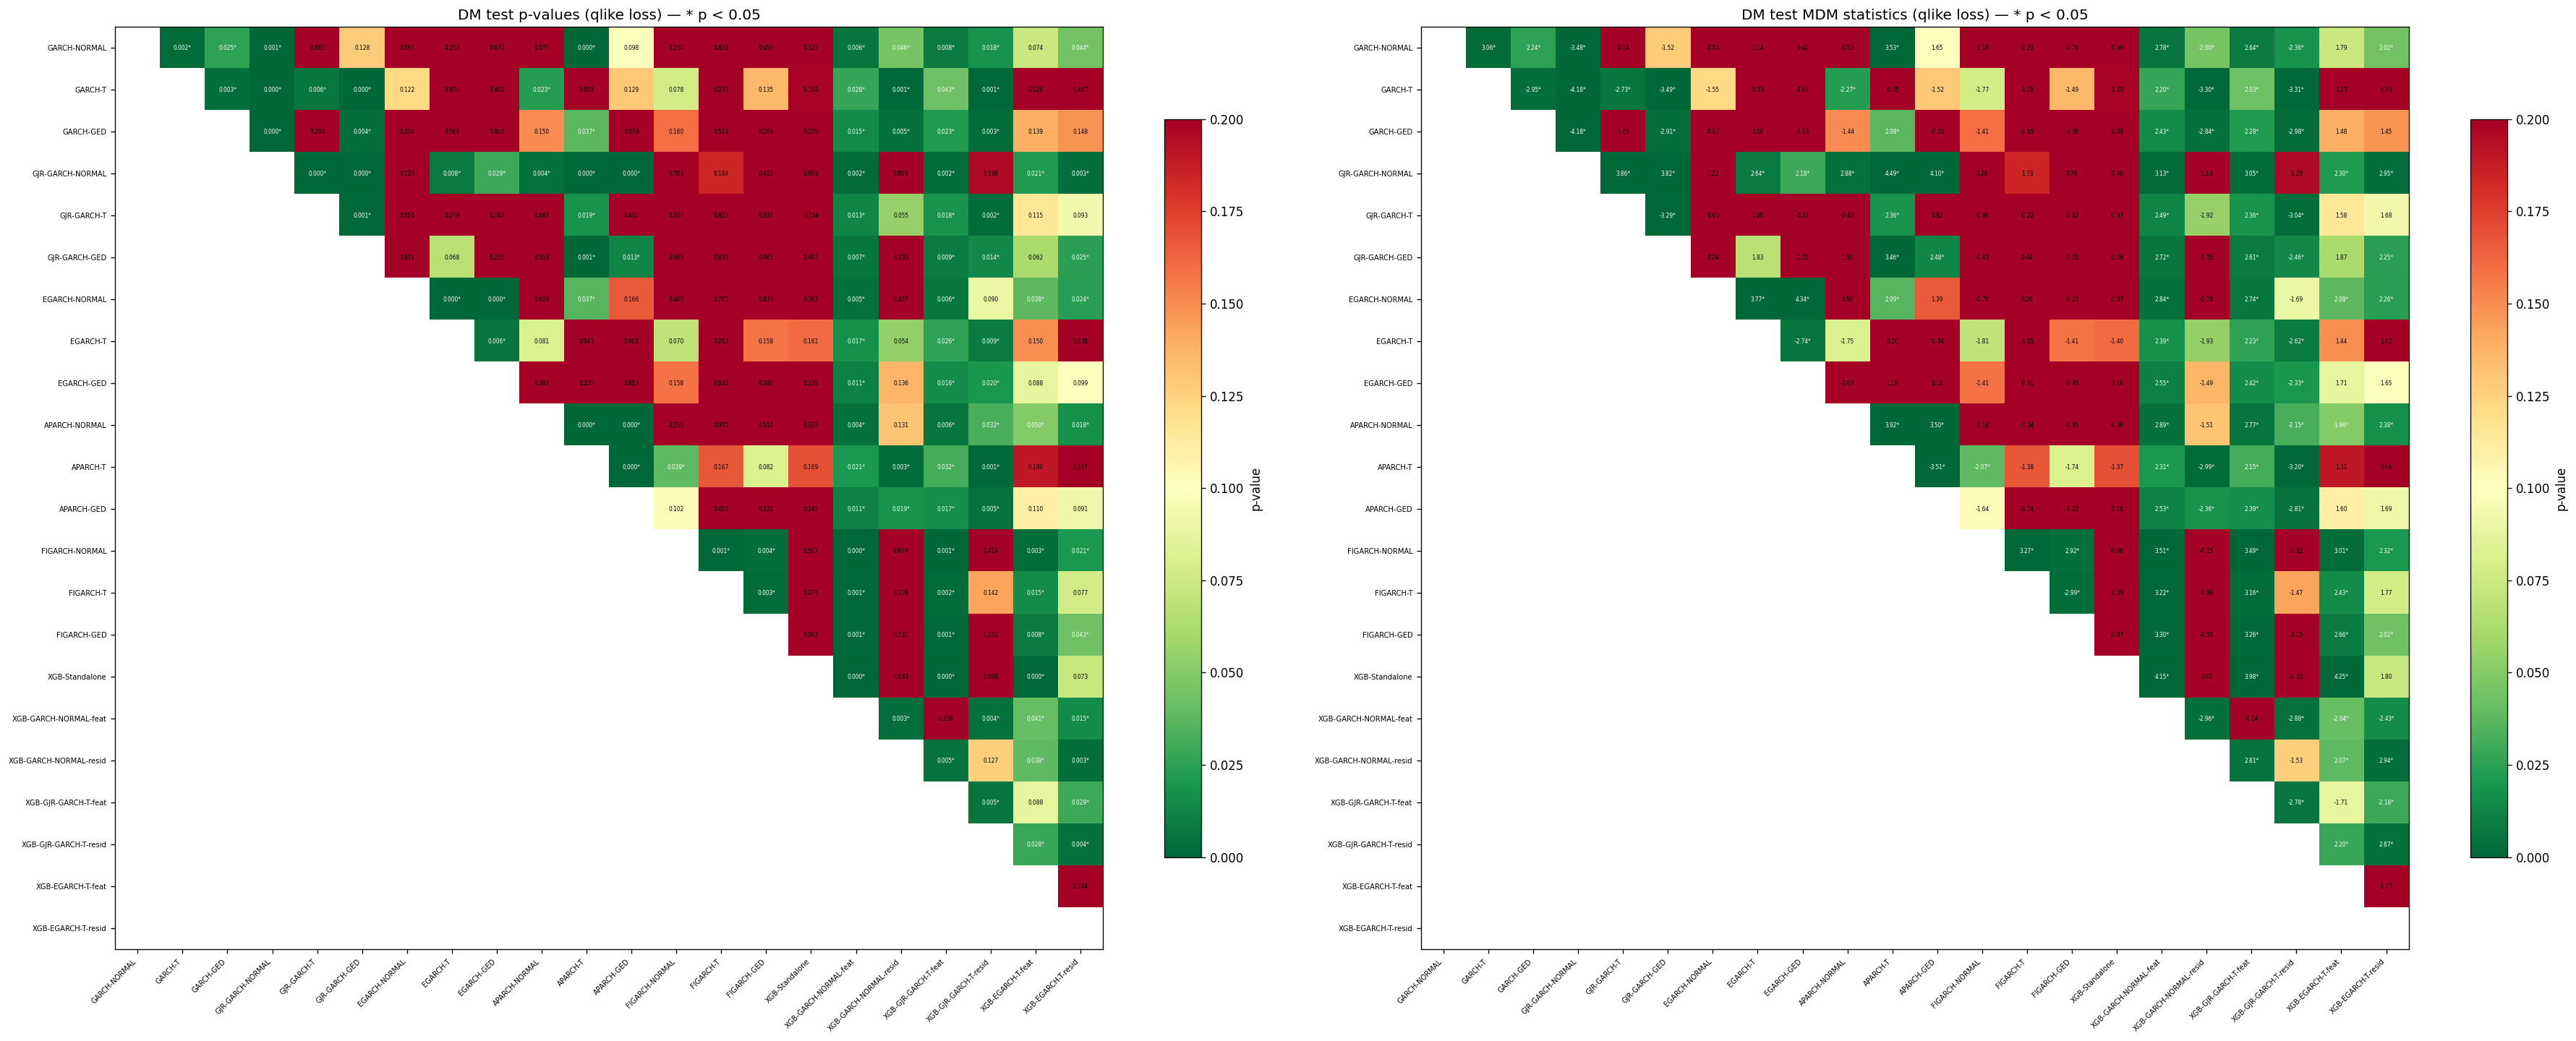

In [ ]:
names  = list(all_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)
stats  = dm_stat_df.values.astype(float)

mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)
stats_plot = np.where(mask, np.nan, stats)

fig, axes = plt.subplots(1, 2, figsize=(max(10, n_mods * 0.7) * 2, max(7, n_mods * 0.55)), dpi=120)

for ax, data, title_suffix, fmt in zip(
    axes,
    [pvals_plot, stats_plot],
    ["p-values", "MDM statistics"],
    ["{:.3f}", "{:.2f}"],
):
    im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
    plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)
    ax.set_xticks(range(n_mods))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=6)
    ax.set_yticks(range(n_mods))
    ax.set_yticklabels(names, fontsize=6)
    ax.set_title(f"DM test {title_suffix} ({TEST_LOSS} loss) — * p < {DM_ALPHA}")
    for i in range(n_mods):
        for j in range(i + 1, n_mods):
            val = data[i, j]
            p   = pvals_plot[i, j]
            if not np.isnan(val):
                sig = "*" if (not np.isnan(p) and p < DM_ALPHA) else ""
                ax.text(j, i, fmt.format(val) + sig,
                        ha="center", va="center", fontsize=4.5,
                        color="white" if (not np.isnan(p) and p < 0.05) else "black")

plt.tight_layout()
plt.show()

## 8.2 Model Confidence Set (MCS)

Hansen, Lunde & Nason (2011). Sequential elimination of the worst model until H₀ of equal
predictive accuracy cannot be rejected. Inference via stationary bootstrap (Politis & Romano 1994).

Models with `mcs_pvalue > MCS_ALPHA` belong to the (1 − MCS_ALPHA) MCS.

In [ ]:
mcs_result = mcs(
    all_results,
    loss=TEST_LOSS,
    alpha=MCS_ALPHA,
    n_boot=2000,
    seed=42,
)
print(mcs_result)
print()
mcs_result.summary().style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["in_mcs"],
).format({"mcs_pvalue": "{:.4f}"})

MCSResult(alpha=0.05, loss='qlike', n_included=22, models=['GARCH-NORMAL', 'GARCH-T', 'GARCH-GED', 'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED', 'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED', 'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED', 'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED', 'XGB-Standalone', 'XGB-GARCH-NORMAL-feat', 'XGB-GARCH-NORMAL-resid', 'XGB-GJR-GARCH-T-feat', 'XGB-GJR-GARCH-T-resid', 'XGB-EGARCH-T-feat', 'XGB-EGARCH-T-resid'])



,mcs_pvalue,in_mcs
GARCH-NORMAL,1.0000,True
GARCH-T,1.0000,True
XGB-EGARCH-T-feat,1.0000,True
XGB-GJR-GARCH-T-resid,1.0000,True
XGB-GJR-GARCH-T-feat,1.0000,True
XGB-GARCH-NORMAL-resid,1.0000,True
XGB-GARCH-NORMAL-feat,1.0000,True
XGB-Standalone,1.0000,True
FIGARCH-GED,1.0000,True
FIGARCH-T,1.0000,True


/var/folders/_v/nfq7618558l9gfbcj7cdk0hm0000gn/T/ipykernel_30990/4292184626.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mcs_df["Model"], rotation=45, ha='right', fontsize=7)


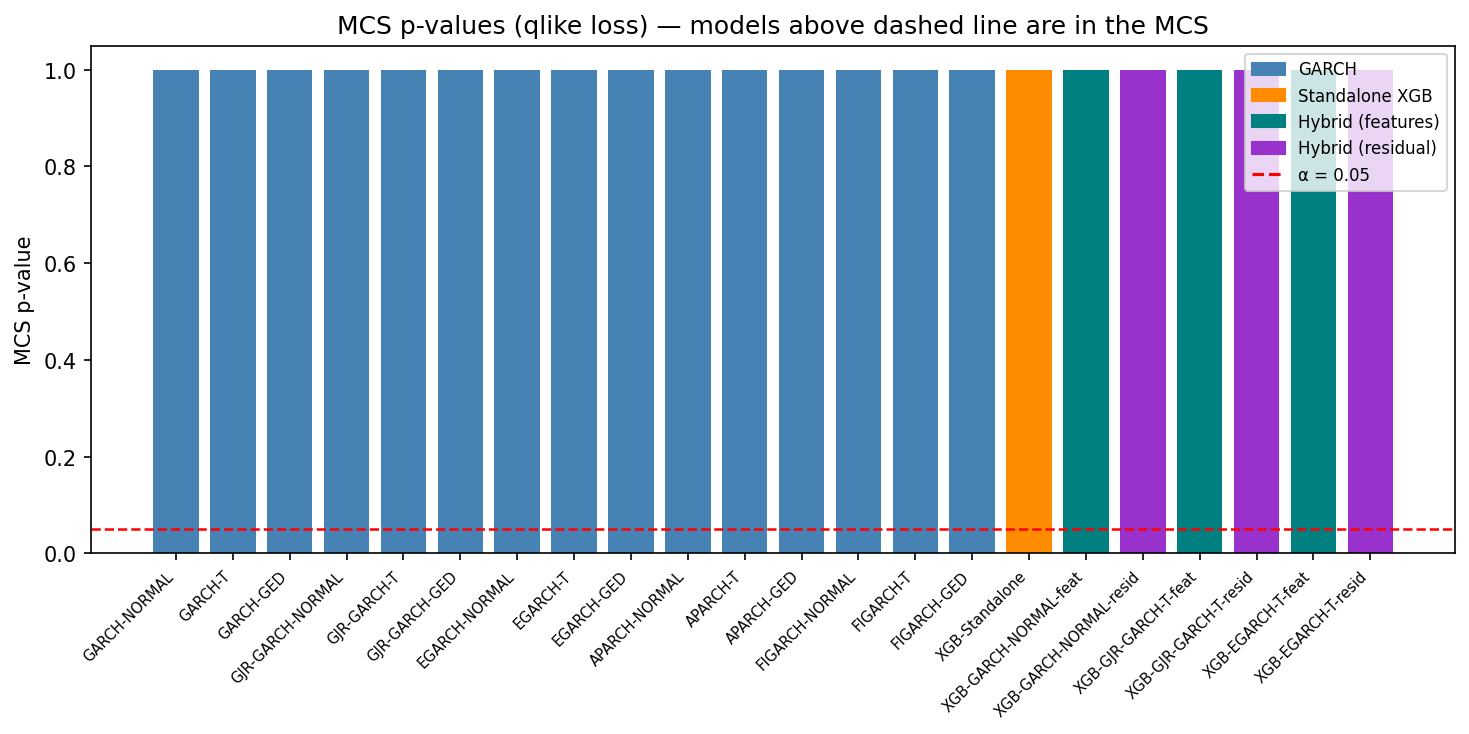

In [ ]:
# MCS summary bar chart — p-values per model coloured by group
mcs_df   = mcs_result.summary().reset_index().rename(columns={"index": "Model"})
mcs_df["Group"] = mcs_df["Model"].map(_group)
mcs_df   = mcs_df.sort_values("mcs_pvalue", ascending=False)

colors = mcs_df["Group"].map({
    "GARCH": "steelblue",
    "Standalone XGB": "darkorange",
    "Hybrid (features)": "teal",
    "Hybrid (residual)": "darkorchid",
}).fillna("gray")

fig, ax = plt.subplots(figsize=(max(8, len(mcs_df) * 0.45), 5), dpi=150)
ax.bar(mcs_df["Model"], mcs_df["mcs_pvalue"], color=colors)
ax.axhline(MCS_ALPHA, color='red', linewidth=1.2, linestyle='--', label=f'α = {MCS_ALPHA}')
ax.set_ylabel("MCS p-value")
ax.set_title(f"MCS p-values ({TEST_LOSS} loss) — models above dashed line are in the MCS")
ax.set_xticklabels(mcs_df["Model"], rotation=45, ha='right', fontsize=7)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='steelblue',  label='GARCH'),
    Patch(color='darkorange', label='Standalone XGB'),
    Patch(color='teal',       label='Hybrid (features)'),
    Patch(color='darkorchid', label='Hybrid (residual)'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'α = {MCS_ALPHA}'),
]
ax.legend(handles=legend_elements, fontsize=8)
plt.tight_layout()
plt.show()